<a href="https://colab.research.google.com/github/pawankeshri/langchain-demo/blob/main/Text_Feature_Extraction_Techniques_19_Sep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Feature Extraction from Text Data — Major Techniques

From Text → Features → Classification

This notebook is the next step after text preprocessing.

We will focus only on the major feature-extraction techniques that are most important for classical NLP and the transition to modern NLP:

    Bag of Words (BoW)
    CountVectorizer
    N-Grams
    TF-IDF
    Word Embeddings
    Word2Vec
    GloVe
    FastText
    Introduction to embedding-based representations

The objective is not just to learn the APIs. We will understand:

    what each technique represents
    how the representation is created
    what information it captures
    what information it loses
    sparse vs dense representations
    when to use each technique
    how the representation becomes input to a text classifier


Real World Example- EComm Product Reviews

In [ ]:
real_reviews = [
    "The phone looks premium and the battery easily lasts all day. Very happy with the purchase.",
    "Excellent camera quality, fast performance, and the display is beautiful. Highly recommended!",
    "The laptop is lightweight and powerful, but the fan gets noisy during heavy use.",
    "Amazing product for the price. Setup was easy and delivery was faster than expected.",
    "The headphones sound great, but the ear cushions are uncomfortable after a few hours.",
    "Terrible battery life. The phone needs to be charged twice a day and gets very hot.",
    "The screen stopped working after one week. Customer support was slow and unhelpful.",
    "Poor build quality and disappointing performance. I would not recommend this product.",
    "The delivery was late, the package was damaged, and the product had scratches.",
    "Not worth the money. The features look good on paper but do not work reliably."
]

real_labels = [
    "positive", "positive", "positive", "positive", "positive",
    "negative", "negative", "negative", "negative", "negative"
]

for review, label in zip(real_reviews, real_labels):
    print(f"{label:10} | {review}")

positive   | The phone looks premium and the battery easily lasts all day. Very happy with the purchase.
positive   | Excellent camera quality, fast performance, and the display is beautiful. Highly recommended!
positive   | The laptop is lightweight and powerful, but the fan gets noisy during heavy use.
positive   | Amazing product for the price. Setup was easy and delivery was faster than expected.
positive   | The headphones sound great, but the ear cushions are uncomfortable after a few hours.
negative   | Terrible battery life. The phone needs to be charged twice a day and gets very hot.
negative   | The screen stopped working after one week. Customer support was slow and unhelpful.
negative   | Poor build quality and disappointing performance. I would not recommend this product.
negative   | The delivery was late, the package was damaged, and the product had scratches.
negative   | Not worth the money. The features look good on paper but do not work reliably.


Feature Extraction from Reviews

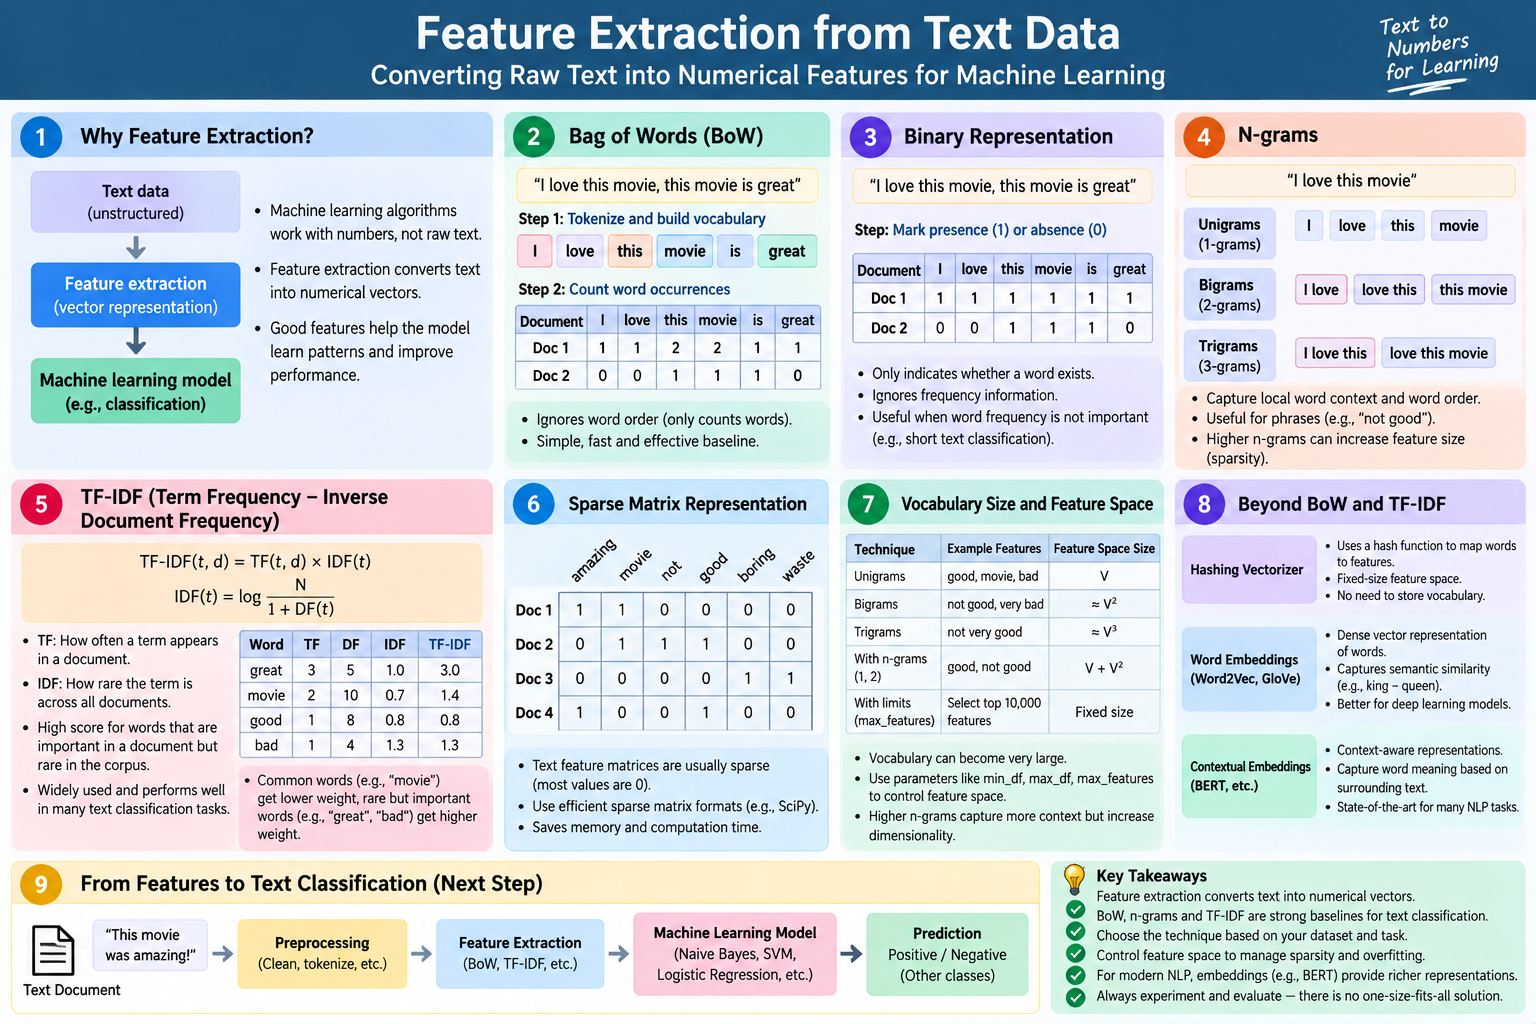

1. Bag of Word (BoW)

BoW represents the document(sentence) using the words that ocuurs in it.

Note: CountVectorizer is the implementation of BoW

2. CountVectorizer (from sklearn librabry)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer=CountVectorizer()

real_count=vectorizer.fit_transform(real_reviews)


print("Doccuments:",real_count.shape[0])  #rows
print("Features:",real_count.shape[1])  #columns

print("\n BoW (Sample vocabulary):")
print(vectorizer.get_feature_names_out()[:100])

Doccuments: 10
Features: 94

 BoW (Sample vocabulary):
['after' 'all' 'amazing' 'and' 'are' 'battery' 'be' 'beautiful' 'build'
 'but' 'camera' 'charged' 'cushions' 'customer' 'damaged' 'day' 'delivery'
 'disappointing' 'display' 'do' 'during' 'ear' 'easily' 'easy' 'excellent'
 'expected' 'fan' 'fast' 'faster' 'features' 'few' 'for' 'gets' 'good'
 'great' 'had' 'happy' 'headphones' 'heavy' 'highly' 'hot' 'hours' 'is'
 'laptop' 'lasts' 'late' 'life' 'lightweight' 'look' 'looks' 'money'
 'needs' 'noisy' 'not' 'on' 'one' 'package' 'paper' 'performance' 'phone'
 'poor' 'powerful' 'premium' 'price' 'product' 'purchase' 'quality'
 'recommend' 'recommended' 'reliably' 'scratches' 'screen' 'setup' 'slow'
 'sound' 'stopped' 'support' 'terrible' 'than' 'the' 'this' 'to' 'twice'
 'uncomfortable' 'unhelpful' 'use' 'very' 'was' 'week' 'with' 'work'
 'working' 'worth' 'would']


In [ ]:
import pandas as pd

# Convert the sparse matrix to a dense array
dense_count = real_count.toarray()

# Create a DataFrame
df_count = pd.DataFrame(dense_count, columns=vectorizer.get_feature_names_out())

# Display the DataFrame
display(df_count)

,after,all,amazing,and,are,battery,be,beautiful,build,but,...,unhelpful,use,very,was,week,with,work,working,worth,would
0,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,0,0,1,1,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
4,1,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,1,0,0,1,0,0,0,0,0,0,...,1,0,0,1,1,0,0,1,0,0
7,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


Alternate: CountVectorizer with Binary BoW  (exactly as one-hot encoding)

**Note: It just show present and absence of the token, not count in the given doccument**

In [ ]:
binary_vectorizer=CountVectorizer(binary=True)

real_count=binary_vectorizer.fit_transform(real_reviews)


print("Doccuments:",real_count.shape[0])  #rows
print("Features:",real_count.shape[1])  #columns

print("\n BoW (Sample vocabulary):")
print(binary_vectorizer.get_feature_names_out()[:100])

Doccuments: 10
Features: 94

 BoW (Sample vocabulary):
['after' 'all' 'amazing' 'and' 'are' 'battery' 'be' 'beautiful' 'build'
 'but' 'camera' 'charged' 'cushions' 'customer' 'damaged' 'day' 'delivery'
 'disappointing' 'display' 'do' 'during' 'ear' 'easily' 'easy' 'excellent'
 'expected' 'fan' 'fast' 'faster' 'features' 'few' 'for' 'gets' 'good'
 'great' 'had' 'happy' 'headphones' 'heavy' 'highly' 'hot' 'hours' 'is'
 'laptop' 'lasts' 'late' 'life' 'lightweight' 'look' 'looks' 'money'
 'needs' 'noisy' 'not' 'on' 'one' 'package' 'paper' 'performance' 'phone'
 'poor' 'powerful' 'premium' 'price' 'product' 'purchase' 'quality'
 'recommend' 'recommended' 'reliably' 'scratches' 'screen' 'setup' 'slow'
 'sound' 'stopped' 'support' 'terrible' 'than' 'the' 'this' 'to' 'twice'
 'uncomfortable' 'unhelpful' 'use' 'very' 'was' 'week' 'with' 'work'
 'working' 'worth' 'would']


In [ ]:
# Convert the sparse matrix to a dense array
dense_count = real_count.toarray()

# Create a DataFrame
df_count = pd.DataFrame(dense_count, columns=binary_vectorizer.get_feature_names_out())

# Display the DataFrame
display(df_count)

#1- token present
#0- token not present

,after,all,amazing,and,are,battery,be,beautiful,build,but,...,unhelpful,use,very,was,week,with,work,working,worth,would
0,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,0,0,1,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,1,0,0,1,0,0,0,0,0,0,...,1,0,0,1,1,0,0,1,0,0
7,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
8,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


**2. TF-IDF**  (Term Freq and Inverse Doc Freq)

Moving Beyond the raw count

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#prod_tfidf=TfidfVectorizer(ngram_range=(1,2))  #with TFIDF+NGram  1-gram and 2-grams
prod_tfidf=TfidfVectorizer()  #Default 1-Gram

X_prod_tfidf=prod_tfidf.fit_transform(real_reviews)

print(X_prod_tfidf)

print("Doccuments:",X_prod_tfidf.shape[0])
print("Features:",X_prod_tfidf.shape[1])


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 126 stored elements and shape (10, 94)>
  Coords	Values
  (0, 79)	0.34274766083833313
  (0, 59)	0.23983278251426973
  (0, 49)	0.2821258911751918
  (0, 62)	0.2821258911751918
  (0, 3)	0.12523912705114745
  (0, 5)	0.23983278251426973
  (0, 22)	0.2821258911751918
  (0, 44)	0.2821258911751918
  (0, 1)	0.2821258911751918
  (0, 15)	0.23983278251426973
  (0, 86)	0.23983278251426973
  (0, 36)	0.2821258911751918
  (0, 89)	0.2821258911751918
  (0, 65)	0.2821258911751918
  (1, 79)	0.13118563756912582
  (1, 3)	0.1438046989784273
  (1, 24)	0.323948512016535
  (1, 10)	0.323948512016535
  (1, 66)	0.275385831143153
  (1, 27)	0.323948512016535
  (1, 58)	0.275385831143153
  (1, 18)	0.323948512016535
  (1, 42)	0.275385831143153
  (1, 7)	0.323948512016535
  (1, 39)	0.323948512016535
  :	:
  (7, 67)	0.3348593497627207
  (7, 80)	0.3348593497627207
  (8, 79)	0.3811157296338017
  (8, 3)	0.13925872219828792
  (8, 64)	0.23331374172118852
  (8, 87)	0.

In [ ]:
#One Review at time
rows=X_prod_tfidf[0].toarray().ravel()
print(rows)
features=prod_tfidf.get_feature_names_out()
print(features)

[0.         0.28212589 0.         0.12523913 0.         0.23983278
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.23983278 0.         0.
 0.         0.         0.         0.         0.28212589 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.28212589 0.         0.         0.         0.         0.
 0.         0.         0.28212589 0.         0.         0.
 0.         0.28212589 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.23983278
 0.         0.         0.28212589 0.         0.         0.28212589
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.34274766 0.         0.         0.         0.
 0.         0.         0.23983278 0.         0.         0.28212589
 0.         0.         0.         0.        ]
['after' 'all' 'amazing' 'and' 'are' 

In [ ]:
top_indices=rows.argsort()[::-1][:50]
print("Review:",real_reviews[5])
print("\nTop TF-IDF ")

for i in top_indices:
  print(f"{features[i]:25} {rows[i]:.2f}")

Review: Terrible battery life. The phone needs to be charged twice a day and gets very hot.

Top TF-IDF 
the                       0.34
with                      0.28
purchase                  0.28
happy                     0.28
looks                     0.28
premium                   0.28
lasts                     0.28
all                       0.28
easily                    0.28
phone                     0.24
day                       0.24
very                      0.24
battery                   0.24
and                       0.13
this                      0.00
to                        0.00
terrible                  0.00
than                      0.00
stopped                   0.00
sound                     0.00
worth                     0.00
working                   0.00
week                      0.00
was                       0.00
use                       0.00
unhelpful                 0.00
uncomfortable             0.00
twice                     0.00
work                      0

In [ ]:
tfidf_df=pd.DataFrame(X_prod_tfidf.toarray(),columns=prod_tfidf.get_feature_names_out())
print(tfidf_df.round(2))

   after   all  amazing   and  are  battery    be  beautiful  build   but  \
0   0.00  0.28     0.00  0.13  0.0     0.24  0.00       0.00   0.00  0.00   
1   0.00  0.00     0.00  0.14  0.0     0.00  0.00       0.32   0.00  0.00   
2   0.00  0.00     0.00  0.13  0.0     0.00  0.00       0.00   0.00  0.23   
3   0.00  0.00     0.29  0.13  0.0     0.00  0.00       0.00   0.00  0.00   
4   0.26  0.00     0.00  0.00  0.3     0.00  0.00       0.00   0.00  0.22   
5   0.00  0.00     0.00  0.13  0.0     0.25  0.29       0.00   0.00  0.00   
6   0.26  0.00     0.00  0.14  0.0     0.00  0.00       0.00   0.00  0.00   
7   0.00  0.00     0.00  0.15  0.0     0.00  0.00       0.00   0.33  0.00   
8   0.00  0.00     0.00  0.14  0.0     0.00  0.00       0.00   0.00  0.00   
9   0.00  0.00     0.00  0.00  0.0     0.00  0.00       0.00   0.00  0.20   

   ...  unhelpful  use  very   was  week  with  work  working  worth  would  
0  ...       0.00  0.0  0.24  0.00  0.00  0.28  0.00     0.00   0.00   0.0

NGrams: Preserving the local sentence structure

Unigram: one Token

Unigram+Bigrams: One token+ Different possible phrases (2 tokens)

In [ ]:
input_doc=[
    "This movie is good.",
    "This movie is not good",
    "This movie is very good"
]

uni_gram_vectorizer=CountVectorizer()
X_phrases=uni_gram_vectorizer.fit_transform(input_doc)
print("Uni_Grams:",uni_gram_vectorizer.get_feature_names_out())

Uni_Grams: ['good' 'is' 'movie' 'not' 'this' 'very']


In [ ]:
bi_gram_vectorizer=CountVectorizer(ngram_range=(1,2))
X_phrases=bi_gram_vectorizer.fit_transform(input_doc)
print("Bi_Grams:",bi_gram_vectorizer.get_feature_names_out())

Bi_Grams: ['good' 'is' 'is good' 'is not' 'is very' 'movie' 'movie is' 'not'
 'not good' 'this' 'this movie' 'very' 'very good']


In [ ]:
tri_gram_vectorizer=CountVectorizer(ngram_range=(1,3))
X_phrases=tri_gram_vectorizer.fit_transform(input_doc)
print("Bi_Grams:",tri_gram_vectorizer.get_feature_names_out())

Bi_Grams: ['good' 'is' 'is good' 'is not' 'is not good' 'is very' 'is very good'
 'movie' 'movie is' 'movie is good' 'movie is not' 'movie is very' 'not'
 'not good' 'this' 'this movie' 'this movie is' 'very' 'very good']


## Word2Vec

Word2Vec learns word vectors from the contexts in which words appear.

It was introduced by Mikolov and colleagues and became one of the most influential approaches to learning distributed word representations.

Two major training architectures are:
1. CBOW — Continuous Bag of Words
Predict the target word from surrounding context.

2. Skip Gram -Predicts the context on the given word

Word2Vec — CBOW vs Skip-gram

| Feature | CBOW | Skip-gram |
|---|---|---|
| Input | Context words | Target word |
| Predicts | Target word | Context words |
| Training | Generally faster | Generally slower |
| Often useful for | Frequent words | Rare words |
| Basic idea | Context → target | Target → context |

The model learns the vectors as part of the training process.

The final embedding matrix contains a vector for each vocabulary item.

### Important insight

Word2Vec is not simply a dictionary of manually assigned semantic values.

The vectors are **learned from word-context relationships**.

## Real-World Intuition — Learning from Context

Suppose a large corpus contains:

```text
The phone battery lasts all day.
The laptop battery lasts all day.
Battery life is excellent.
The battery drains quickly.
```

The word `battery` repeatedly appears near words such as:

```text
phone, laptop, lasts, life, excellent, drains
```

Word2Vec learns from these context patterns.

It is not explicitly told that battery is related to power or devices. Useful relationships emerge from repeated word-context patterns.

This is the foundation of **distributional semantics**:

> Words that occur in similar contexts tend to develop similar vector representations.

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 47.0 MB/s eta 0:00:00


In [ ]:
# Word2Vec toy example

from gensim.models import Word2Vec

sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "mat"],
    ["the", "cat", "chased", "the", "mouse"],
    ["the", "dog", "chased", "the", "ball"],
    ["the", "kitten", "played", "with", "the", "ball"],
    ["the", "puppy", "played", "with", "the", "ball"],
    ["the","Car","is","black"]
]

#Model Building/Training
word2vec = Word2Vec(
    sentences,
    vector_size=50,
    window=2,   #Context window, larger context window better contexual relationship
    min_count=1,
    workers=1,
    sg=0,   #Skip_gram  1- skip gram, 0- CBOW
    epochs=100
)

print(word2vec.wv["dog"][:10])
print("\nSimilar words to 'dog':")
print(word2vec.wv.most_similar("dog", topn=5))

[ 0.00259602 -0.00525667 -0.01413139 -0.01553862 -0.0186499  -0.01224817
 -0.0031149  -0.00812155 -0.01330156 -0.00800303]

Similar words to 'dog':
[('puppy', 0.31508007645606995), ('cat', 0.22867396473884583), ('is', 0.21536196768283844), ('mat', 0.20585204660892487), ('Car', 0.11592903733253479)]


In [ ]:
print(word2vec.wv["Car"][:10]) #out of corpus/context
print("\nSimilar words to 'Car':")
print(word2vec.wv.most_similar("Car", topn=5))

[ 0.01613489 -0.00903264 -0.00210874  0.00212684 -0.0007181   0.00210988
  0.01267407  0.00021894 -0.0068944  -0.00337696]

Similar words to 'Car':
[('played', 0.19759976863861084), ('kitten', 0.19694668054580688), ('is', 0.19255273044109344), ('on', 0.13162150979042053), ('dog', 0.11592904478311539)]


# GloVe

**GloVe = Global Vectors for Word Representation.**

GloVe learns word vectors using **global word co-occurrence statistics**.

This is an important conceptual difference from Word2Vec.

### Word2Vec

Focuses on predicting words from local context.

```text
word ↔ surrounding context
```

### GloVe

Uses a global word-word co-occurrence matrix.

```text
How often do words occur together
across the corpus?
```

The model learns vectors that encode useful information from these co-occurrence patterns.

### Intuition

If:

```text
king
queen
prince
```

occur in similar contexts, their vectors can become related.

GloVe therefore combines information from global corpus statistics with dense vector learning.

Word2Vec vs GloVe

| Feature | Word2Vec | GloVe |
|---|---|---|
| Main idea | Predict context | Model global co-occurrence |
| Training view | Local context prediction | Global word-word statistics |
| Representation | Dense vectors | Dense vectors |
| Semantic relationships | Yes | Yes |
| Context-specific vector? | No | No |
| OOV handling | No | No |
| Common use | Pre-trained embeddings / NLP | Pre-trained embeddings / NLP |

### Simple memory aid

**Word2Vec:** learn by predicting context.

**GloVe:** learn from global co-occurrence statistics.

In [ ]:
# GloVe toy example

from gensim.scripts.glove2word2vec import glove2word2

sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "mat"],
    ["the", "cat", "chased", "the", "mouse"],
    ["the", "dog", "chased", "the", "ball"],
    ["the", "kitten", "played", "with", "the", "ball"],
    ["the", "puppy", "played", "with", "the", "ball"],
    ["the","Car","is","black"]
]

#Model Building/Training
word2vec = glove2word2(
    sentences,
    vector_size=50,
    window=2,   #Context window, larger context window better contexual relationship
    min_count=1,
    workers=1,
    sg=0,   #Skip_gram  1- skip gram, 0- CBOW
    epochs=100
)

print(word2vec.wv["dog"][:10])
print("\nSimilar words to 'dog':")
print(word2vec.wv.most_similar("dog", topn=5))

ImportError: cannot import name 'glove2word2' from 'gensim.scripts.glove2word2vec' (/usr/local/lib/python3.13/dist-packages/gensim/scripts/glove2word2vec.py)

### Loading Pre-trained GloVe Embeddings

Gensim doesn't directly train GloVe models from raw text in the same way it does Word2Vec. Instead, it provides utilities to work with *pre-trained* GloVe embeddings. The general process involves:

1.  **Downloading** a pre-trained GloVe file (often from Stanford's NLP group).
2.  **Converting** the GloVe format to a Word2Vec-compatible format using `gensim.scripts.glove2word2vec.glove2word2vec`.
3.  **Loading** the converted model using `gensim.models.KeyedVectors.load_word2vec_format`.

In [ ]:
# Download a small pre-trained GloVe model
# We'll use a small one for demonstration purposes (e.g., 50-dimensional vectors trained on Wikipedia + Gigaword 5)
# This might take a moment depending on your internet connection.

import os
import urllib.request

glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_file = "glove.6B.zip"
glove_vec_file = "glove.6B.50d.txt"

if not os.path.exists(glove_zip_file):
    print(f"Downloading {glove_zip_file}...")
    urllib.request.urlretrieve(glove_url, glove_zip_file)
    print("Download complete.")
else:
    print(f"{glove_zip_file} already downloaded.")

import zipfile

if not os.path.exists(glove_vec_file):
    print(f"Extracting {glove_vec_file} from {glove_zip_file}...")
    with zipfile.ZipFile(glove_zip_file, 'r') as zip_ref:
        zip_ref.extract(glove_vec_file, path=".")
    print("Extraction complete.")
else:
    print(f"{glove_vec_file} already extracted.")

KeyboardInterrupt: 

In [ ]:
# Convert the GloVe format to Word2Vec format
from gensim.scripts.glove2word2vec import glove2word2vec

glove_input_file = glove_vec_file
word2vec_output_file = 'glove.6B.50d.word2vec.txt'

if not os.path.exists(word2vec_output_file):
    print(f"Converting {glove_input_file} to Word2Vec format...")
    glove2word2vec(glove_input_file, word2vec_output_file)
    print("Conversion complete.")
else:
    print(f"{word2vec_output_file} already exists.")

In [ ]:
# Load the converted GloVe model using Gensim's KeyedVectors
from gensim.models import KeyedVectors

print("Loading GloVe model...")
# The 'binary=False' parameter indicates that the file is not in binary format
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)
print("GloVe model loaded successfully!")

# Now you can use the loaded GloVe model similar to Word2Vec
print("\nVector for 'dog':")
print(glove_model['dog'][:10])

print("\nSimilar words to 'dog':")
print(glove_model.most_similar('dog', topn=5))

print("\nSimilar words to 'computer':")
print(glove_model.most_similar('computer', topn=5))